In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

In [27]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Dimensions du dataset : {df.shape}")
print("\nTypes de données originaux :")
print(df.dtypes)
print("\nPremières lignes :")
df.head()

Dimensions du dataset : (7043, 21)

Types de données originaux :
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Premières lignes :


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [28]:
# 1. Rechercher les valeurs nulles (NaN) dans tout le dataframe
print("Valeurs Nulles (NaN) par colonne :")
nuls = df.isnull().sum()
print(nuls[nuls > 0] if nuls.sum() > 0 else "Il n'y a pas de valeurs nulles (NaN).")

# 2. Rechercher les espaces vides (" ") dans toutes les colonnes de texte
print("\nEspaces vides cachés par colonne (uniquement les variables de texte) :")
for col in df.select_dtypes(include=['object']).columns:
    espaces = df[col].astype(str).str.strip().eq('').sum()
    if espaces > 0:
        print(f" - {col} : {espaces} lignes vides")

Valeurs Nulles (NaN) par colonne :
Il n'y a pas de valeurs nulles (NaN).

Espaces vides cachés par colonne (uniquement les variables de texte) :
 - TotalCharges : 11 lignes vides


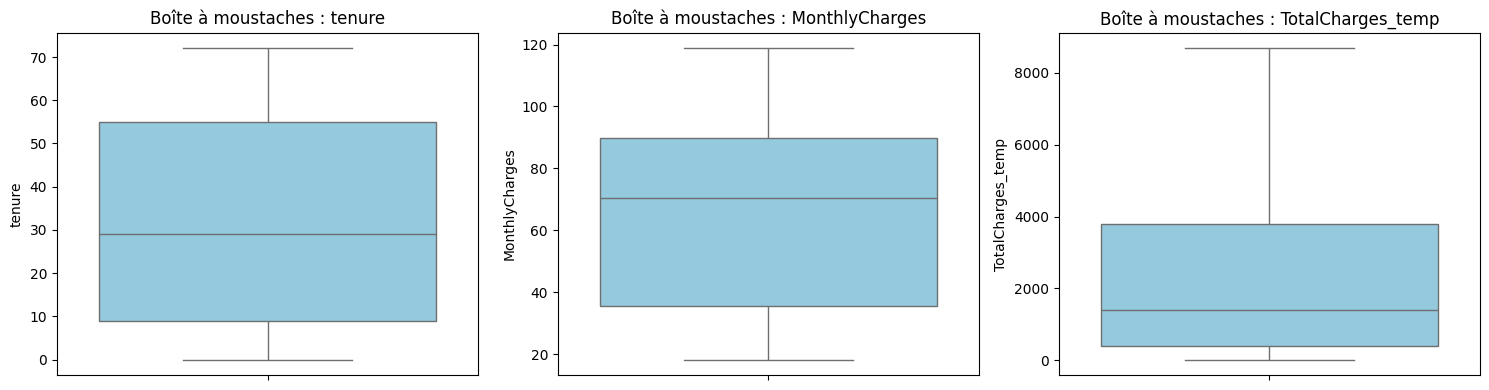

In [29]:

#  Détection des valeurs aberrantes (outliers)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colonnes_numeriques = ['tenure', 'MonthlyCharges', 'TotalCharges_temp']

df['TotalCharges_temp'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

for ax, colonne in zip(axes, colonnes_numeriques):
    sns.boxplot(y=df[colonne], ax=ax, color='skyblue')
    ax.set_title(f"Boîte à moustaches : {colonne}")

plt.tight_layout()
plt.show()

In [30]:
churn_dist = df['Churn'].value_counts(normalize=True) * 100
print("Répartition de Churn (%) :")
print(churn_dist)

Répartition de Churn (%) :
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [31]:
print(f"Identifiants uniques : {df['customerID'].nunique()} sur {len(df)} enregistrements.")
print(f"Lignes entièrement dupliquées : {df.duplicated().sum()}")

Identifiants uniques : 7043 sur 7043 enregistrements.
Lignes entièrement dupliquées : 0


In [32]:
# Comme TotalCharges est actuellement du texte (object), nous devons la convertir en numérique
# en forçant les erreurs (les espaces vides deviendront temporairement NaN)
df['TotalCharges_temp'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Statistiques des variables numériques (y compris la variable temporaire)
print("Statistiques Descriptives (Variables Numériques) :")
display(df[['tenure', 'MonthlyCharges', 'TotalCharges_temp']].describe())

# Statistiques des variables catégorielles
print("\nStatistiques Descriptives (Variables Catégorielles) :")
display(df.describe(include=['object']))

# Nous supprimons la colonne temporaire pour ne pas affecter le code original
df = df.drop(columns=['TotalCharges_temp'])

Statistiques Descriptives (Variables Numériques) :


,tenure,MonthlyCharges,TotalCharges_temp
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000



Statistiques Descriptives (Variables Catégorielles) :


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


--- Taux de Churn selon Contract (%) ---
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83



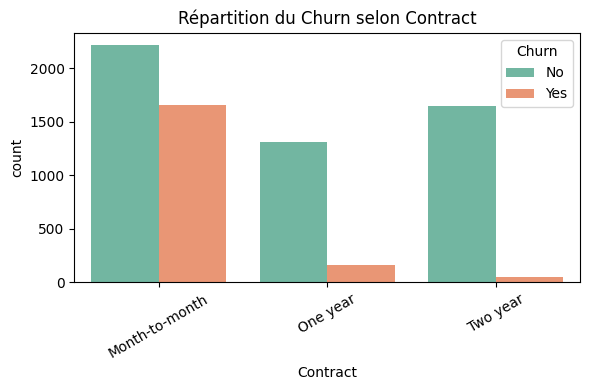

--- Taux de Churn selon PaymentMethod (%) ---
Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11



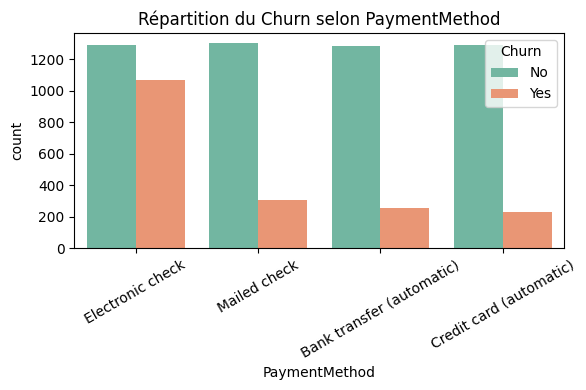

--- Taux de Churn selon InternetService (%) ---
Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40



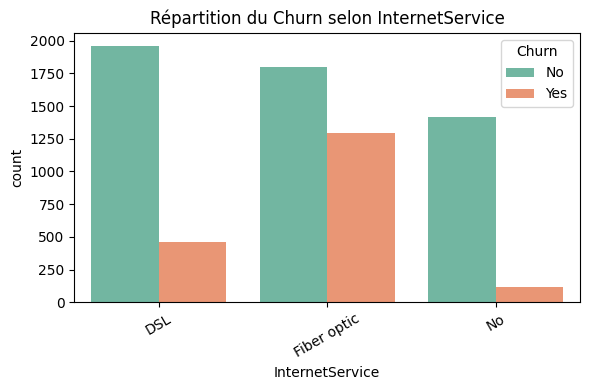

--- Taux de Churn selon TechSupport (%) ---
Churn                   No    Yes
TechSupport                      
No                   58.36  41.64
No internet service  92.60   7.40
Yes                  84.83  15.17



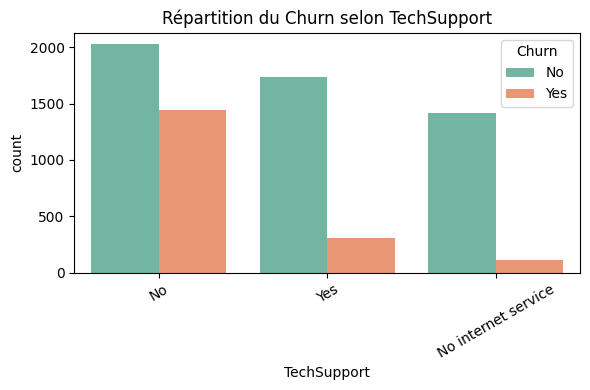

--- Taux de Churn selon OnlineSecurity (%) ---
Churn                   No    Yes
OnlineSecurity                   
No                   58.23  41.77
No internet service  92.60   7.40
Yes                  85.39  14.61



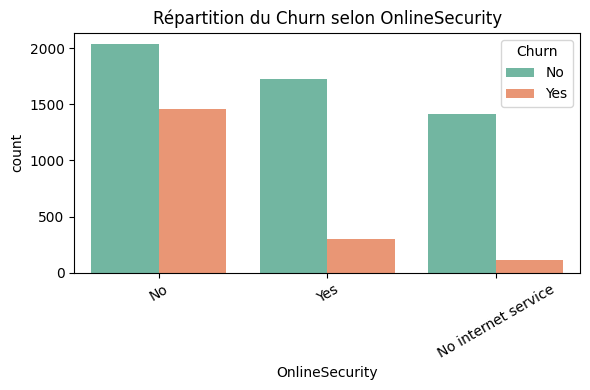

In [33]:

# Variables catégorielles vs Churn (taux de résiliation)

variables_categorielles_cles = [
    'Contract',
    'PaymentMethod',
    'InternetService',
    'TechSupport',
    'OnlineSecurity'
]

for colonne in variables_categorielles_cles:
    print(f"--- Taux de Churn selon {colonne} (%) ---")
    tableau_croise = pd.crosstab(df[colonne], df['Churn'], normalize='index') * 100
    print(tableau_croise.round(2))
    print()

    plt.figure(figsize=(6, 4))
    sns.countplot(x=colonne, hue='Churn', data=df, palette='Set2')
    plt.title(f"Répartition du Churn selon {colonne}")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

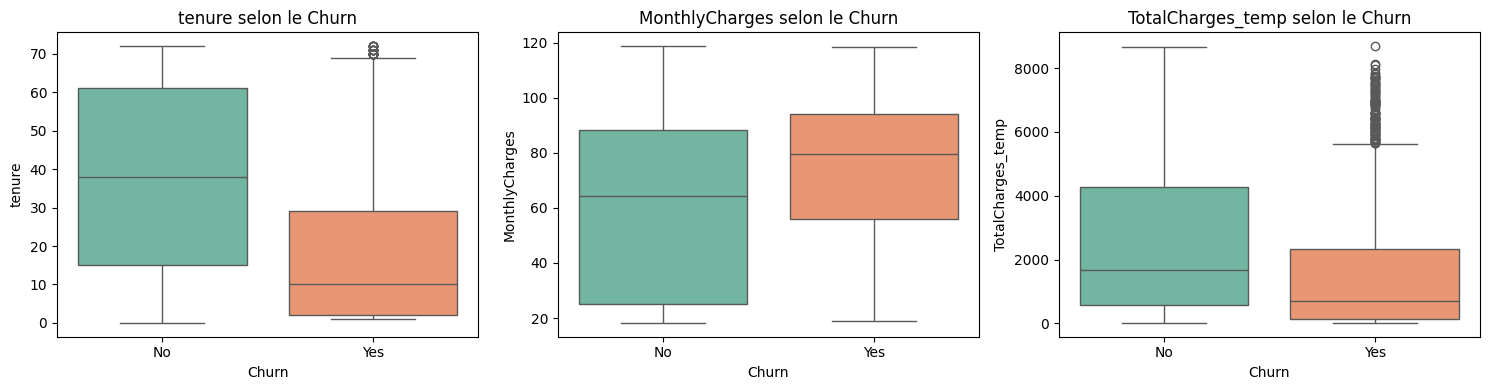

Corrélation des variables numériques avec le Churn :
tenure              -0.352
MonthlyCharges       0.193
TotalCharges_temp   -0.199
Churn_binaire        1.000
Name: Churn_binaire, dtype: float64


In [34]:
# Variables numériques vs Churn

# Recréer la colonne temporaire (supprimée après les statistiques descriptives)
df['TotalCharges_temp'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, colonne in zip(axes, colonnes_numeriques):
    sns.boxplot(x='Churn', y=colonne, data=df, ax=ax, palette='Set2')
    ax.set_title(f"{colonne} selon le Churn")

plt.tight_layout()
plt.show()

# Corrélation point-bisériale simplifiée : Churn encodé en 0/1
df['Churn_binaire'] = df['Churn'].map({'Yes': 1, 'No': 0})

correlation_avec_churn = df[colonnes_numeriques + ['Churn_binaire']].corr()['Churn_binaire']
print("Corrélation des variables numériques avec le Churn :")
print(correlation_avec_churn.round(3))

# Nettoyage des colonnes temporaires pour ne pas polluer df
df = df.drop(columns=['TotalCharges_temp', 'Churn_binaire'])

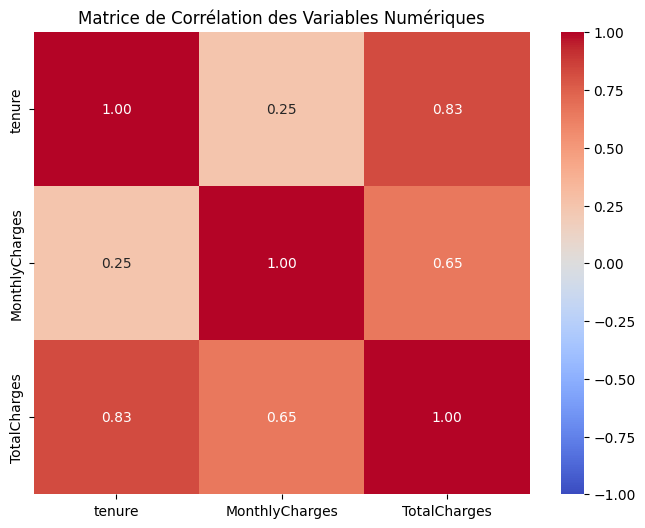

In [35]:
# Ignorer les avertissements pour garder le notebook propre
warnings.filterwarnings('ignore')

# Créer un sous-dataframe uniquement avec les variables numériques
num_vars = df[['tenure', 'MonthlyCharges']].copy()
num_vars['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Calculer la corrélation de Pearson
correlacion = num_vars.corr()

# Visualiser en utilisant une carte thermique (Heatmap) de Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Matrice de Corrélation des Variables Numériques")
plt.show()